# Plotting with Python

This script will plot the results of your manual analysis of the time fish spent in each section of the tank

Your tasks will be as follows.  See the sample plot and description of the anlaysis below:
1. Upload the CSV file
2. Update the *path* to the CSV file (where should the computer look for this file?)
3. Update which columns you want to read in (?)
4. Update the line colors/styles
5. Put labels on the graph
6. Answer the questions about your graph/analysis

## [Binder link to this notebook](https://mybinder.org/v2/gh/heattard/NU-Camp-2026/HEAD)

## A description and sample plot



### The first thing we always need to do is import *packages* that we will use.  

Run the below block of code by selecting the code block and hitting "shift + enter."  This will read in the packages.  

In [4]:
import pandas as pd #pandas gives an helpful way to deal with two-dimensional data (columns and rows)
import numpy as np #this has more math options
import matplotlib.pyplot as plt #plotting.  Based on MATLAB

### Now we need to read in the data file.

In the below cell, replace the words `'your file'` with the *path* and *name* of your file.  

To get the file with a path select the three dots next to the file name in the file tree on the left and select **Copy path**

You can then paste this path where it says `'your file'`.  Keep the apostrophere's on either side of the filename! This tells the computer to read it direclty as it's shown.

The `/` tell the computer what *directory* (or folder) to look in.

Run the cell below and look at the ouptut.  That's your data that is now all held in the variable `df`

`df` stands for **dataframe** which is what pandas calls a table of data

In [5]:
df = pd.read_csv('/content/KK__LDT__sample-data.csv') # read in the data
df #print the data

,Fish,Region,Start,End
0,5597,LightSide,0.00,58.76
1,5597,LightSide,62.01,70.00
2,5597,LightSide,75.03,77.19
3,5597,LightSide,78.10,84.21
4,5597,LightSide,87.38,93.42
...,...,...,...,...
260,3002,DarkSide,496.25,496.67
261,3002,DarkSide,511.84,526.50
262,3002,DarkSide,527.49,529.85
263,3002,DarkSide,546.51,554.74


### If we only want to print information on one column we can type `df['ColumnName']`

Run the cell below to see how it only prints out information about the location the fish was in

> **Challenge 1**: Print out the fish identifiers instead

> **Challenge 2**: Print out the fish identifiers *and* region

In [36]:
df['Region']

,Region
0,LightSide
1,LightSide
2,LightSide
3,LightSide
4,LightSide
...,...
260,DarkSide
261,DarkSide
262,DarkSide
263,DarkSide


### Find the total amount of time in each line

This block of code finds the total amount of time in each row by subtracting the start and end times for each row and putting it in a new column called `time_delta`

> In the cell below, add a new line that prints out the dataframe. Compare it to the dataframe you printed out originally -- whats different?

In [6]:
df['time_delta'] = df['End']-df['Start ']

### Group the data

The `groupby` function is specific to pandas and takes all of the data and "groups" it based on the columns we input.  The lines below groups the data by each fish identfier *and* region (i.e., light or dark).

We will then be able to *access* these groups later

In [37]:
df_fish = df.groupby(['Fish','Region']) #groups the data by identifer AND region

### Find the unique fish identifiers

Each row of data is from a different observation, so each fish has mutiple rows of data.  We can find the ID of each fish by looking at the `Fish` column and getting only the *unique* fish IDs

In [11]:
unique_fish = df['Fish'].unique() #from the column named "fish" grab only the unique values
print(unique_fish) #print them, this is a list
for u in unique_fish: #Loop through the list, assign each value in the list to the variable u
  print(u) #print that unique identifier

[5597 9797 3002]
5597
9797
3002


## Get the groups that we made

We grouped the data by their Fish identifier *and* by their location (lightside or darkside)

Grab the data for one of the fish and al the data for that fish in the light side.

`unique_fish` is a list, which we can see above, when we printed it and it was number in brackets (`[]`).  We can get each element in this array by putting which index we want in brackets. So, `unique_fish[0]` will give the *first* element, `unique_fish[1]` will give the *second* element.  

> **Challenge 1:** If an array has 5 elements, what is the largest index you can put in brackets?

> **Challenge 2:** After you print out the information for the light side, print the information for the dark side

> **Challenge 3:** Print the information for the next unique fish identifier

In [12]:
df_fish.get_group((unique_fish[0],'LightSide'))
#df_fish.head() #

,Fish,Region,Start,End,time_delta
0,5597,LightSide,0.00,58.76,58.76
1,5597,LightSide,62.01,70.00,7.99
2,5597,LightSide,75.03,77.19,2.16
3,5597,LightSide,78.10,84.21,6.11
4,5597,LightSide,87.38,93.42,6.04
5,5597,LightSide,99.71,100.56,0.85
6,5597,LightSide,102.25,113.15,10.90
7,5597,LightSide,114.65,115.47,0.82
8,5597,LightSide,120.54,120.99,0.45
9,5597,LightSide,127.86,128.13,0.27


### Sum up the data in one-minute increments.

We want to konw how long the fish spent in each section for one-minute increments.  

For example, from 0-60s, how long was the fish in the light side? Dark side?  We can then plot that to see where it spent the most time for each minute from 0-9.

The below code sums this up and plots the data.  Look throuhg and run the code as is to see how it outputs, then try some of the challenges below. You will only be changing the plot, not how it finds the minute increments

[  0  60 120 180 240 300 360 420 480 540]
new total: 60.0


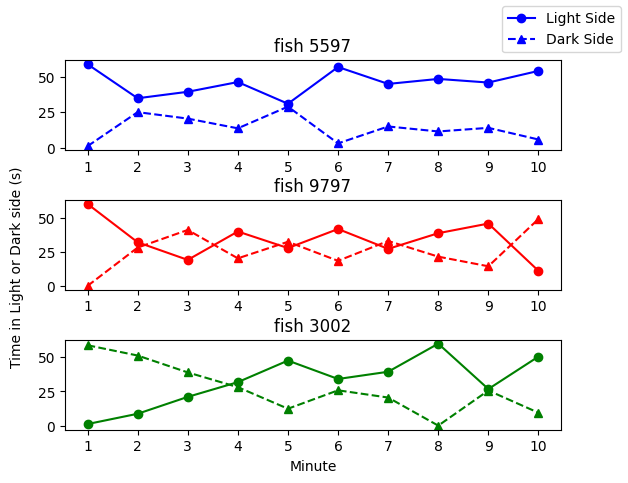

In [35]:
total_mins = 9 #how much time we have
minutes = np.arange(0,60*total_mins+60,60) # make a list of times from 0 to total_mins; +1 b/c not inclusive
print(minutes) #prints it out
minute_binsL = np.zeros(len(minutes)) #this will hold the data for each minute for the light side
minute_binsD = np.zeros(len(minutes)) #same as above but for the dark side

x_axis = np.arange(1,total_mins+2,1) #the x-axis labels will start at 1 minute
color_array = ['blue','red','green','magenta','teal','black'] #the possible colors for plotting the lines
plot_color = color_array[0:len(unique_fish)] #only take as many colors as there are fish

fig, axs = plt.subplots(len(unique_fish),sharex=True) #the same number of plots as there are fish

for i,u in enumerate(unique_fish): #loop through each fish.  u will be the fish ID, i will be a counter starting at 0
  ##############
  ##### This is all getting the data
  #####################
  dataL = df_fish.get_group((u,'LightSide')) #getting the data for each fish and each side
  dataD = df_fish.get_group((u,'DarkSide'))

  for j,t in enumerate(minutes): #loop through each minute to get data for that minute
    #starting at 0 seconds, ending at 600 seconds, every 60 s

    minute_binsL[j] = minute_binsL[j] + np.round(dataL[(dataL['Start '] >= t) & (dataL['End'] < t+60)]['time_delta'].sum(),2)
    minute_binsD[j] = minute_binsD[j] + np.round(dataD[(dataD['Start '] >= t) & (dataD['End'] < t+60)]['time_delta'].sum(),2)


    for l in range(len(dataL)):
      if (dataL['Start '].iloc[l] < t +60 ) and (dataL['End'].iloc[l] > t + 60):

        if (t > dataL['Start '].iloc[l] ): #check if the starting time is ALSO between these times:
          minute_binsL[j] = np.round(minute_binsL[j] + ( (t+60) - t),2)
          print(f'new total: {minute_binsL[j]}')
        else:
          minute_binsL[j] = np.round(minute_binsL[j] + ( (t+60) - dataL['Start '].iloc[l]),2)
          if dataL['End'].iloc[l] > t+120:
            continue
          else:
            minute_binsL[j+1] = np.round(minute_binsL[j+1] + np.abs((t+60) - dataL['End'].iloc[l]),2)

    for l in range(len(dataD)):
      if (dataD['Start '].iloc[l] < t +60 ) and (dataD['End'].iloc[l] > t + 60):
        minute_binsD[j] = np.round(minute_binsD[j] + ( (t+60) - dataD['Start '].iloc[l]),2)
        minute_binsD[j+1] = np.round(minute_binsD[j+1] + np.abs((t+60) - dataD['End'].iloc[l]),2)
    #print(minute_binsL)

  #######################
  ####This is the plotting
  ##### The code makes one plot in each loop, one plot per fish
  ##################

  axs[i].plot(x_axis,minute_binsL,marker='o',color=plot_color[i])
  axs[i].plot(x_axis,minute_binsD,marker='^',color=plot_color[i],linestyle='dashed')
  plt.xticks(x_axis,x_axis)#,rotation=45, ha='right')
  #axs[i].legend()
  axs[i].set_title(f'fish {u}')
  axs[i].tick_params(axis='x', labelbottom=True) #label x tick marks on each plot
  del(minute_binsD,minute_binsL,dataL,dataD)
  minute_binsL = np.zeros(len(minutes))
  minute_binsD = np.zeros(len(minutes))

#########
###Now we are out of the loop and making the three-panel plot prettier
################

plt.subplots_adjust(hspace=0.55) #add some space between the plots, vertically
plt.xlabel("Minute") #label the x axis
plt.gcf().text(0.05,0.45, "Time in Light or Dark side (s)", ha="center", va="center", rotation=90) #one label for all y axes

fig.legend(labels=['Light Side','Dark Side']) #make a legend
